#Projeto Telecom X: Análise de Churn (Evasão de Clientes)

Contexto: A Telecom X, empresa do setor de telecomunicações, identificou uma alta taxa de evasão de clientes. Este projeto faz parte de uma iniciativa estratégica de Data Science para entender os motivos dessa perda e preparar os dados para futuros modelos preditivos.

Objetivo: Realizar o processo completo de ETL (Extração, Transformação e Carga) e EDA (Análise Exploratória de Dados), identificando padrões comportamentais e demográficos que correlacionam com o cancelamento de serviços.

Ferramentas Utilizadas: Python, Pandas, Seaborn e Matplotlib.

###Importando bibliotecas

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure

###Extração de dados

In [24]:


URL_FONTE = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
ESTILO_VISUAL = {'palette': ['#2a9d8f', '#e76f51'], 'style': 'whitegrid'} # Verde e Coral
sns.set_theme(style=ESTILO_VISUAL['style'])


###Carga e ETL

In [25]:
def executar_etl(url):
    raw_data = pd.read_json(url)

    # Normalização em bloco (Flattening)
    df_final = pd.concat([
        raw_data.drop(['customer', 'phone', 'internet', 'account'], axis=1),
        pd.json_normalize(raw_data['customer']),
        pd.json_normalize(raw_data['phone']),
        pd.json_normalize(raw_data['internet']),
        pd.json_normalize(raw_data['account'])
    ], axis=1)

    # Limpeza de nomes e tipagem
    df_final.columns = df_final.columns.str.lower().str.replace('.', '_')

    # Tratamento de campos numéricos e nulos
    df_final['charges_total'] = pd.to_numeric(df_final['charges_total'], errors='coerce').fillna(0)
    df_final['charges_monthly'] = pd.to_numeric(df_final['charges_monthly'], errors='coerce')

    # Mapeamento Binário (Substituindo o replace antigo para evitar warnings)
    mapa_binario = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
    df_final = df_final.replace(mapa_binario)

    # Nova métrica: Ticket Médio Diário
    df_final['ticket_diario'] = (df_final['charges_monthly'] / 30).round(2)

    return df_final

df_telecom = executar_etl(URL_FONTE)

/tmp/ipykernel_141/3395505722.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.replace(mapa_binario)


###Dicionario

In [26]:
dicionario_colunas = {
    'customerid': 'id_assinante',
    'churn': 'evasao',
    'gender': 'sexo_masculino',
    'tenure': 'meses_base',
    'charges_monthly': 'fatura_mensal',
    'charges_total': 'fatura_total',
    'contract': 'tipo_contrato',
    'paymentmethod': 'metodo_pagamento'
}
df_telecom.rename(columns=dicionario_colunas, inplace=True)

###EDA

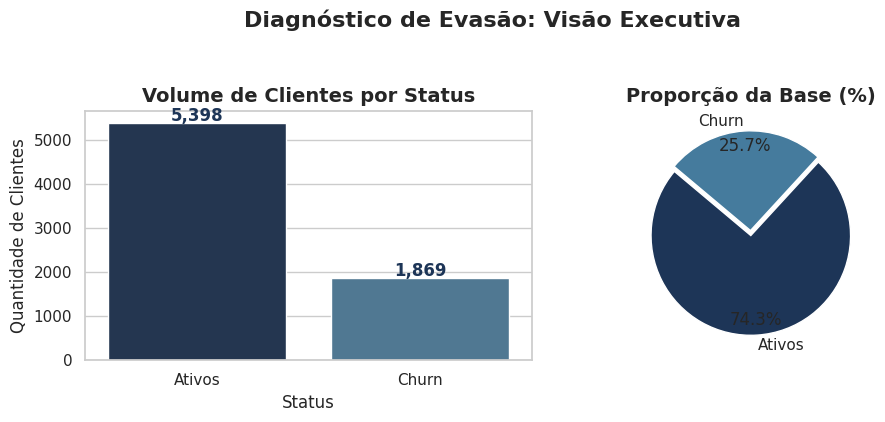

In [45]:


# 1. Filtro e Preparação
df_plot = df_telecom[df_telecom['evasao'].isin([0, 1])]
counts = df_plot['evasao'].value_counts().sort_index()

# 2. Paleta: Azul Profundo (Ativo) e Cinza Escuro (Churn)
cores_executivas = ['#1d3557', '#457b9d']
labels_status = ['Ativos', 'Churn']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- GRÁFICO DE BARRAS (Frequência Absoluta) ---
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], hue=counts.index, palette=cores_executivas, legend=False)
axes[0].set_title('Volume de Clientes por Status', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels_status)
axes[0].set_ylabel('Quantidade de Clientes')
axes[0].set_xlabel('Status')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', color='#1d3557')

# --- GRÁFICO DE PIZZA (Participação Percentual) ---
explode_dinamico = [0.05 if x == 1 else 0 for x in counts.index]
axes[1].pie(counts, labels=labels_status, autopct='%1.1f%%', colors=cores_executivas,
            startangle=140, explode=explode_dinamico, pctdistance=0.85)
axes[1].set_title('Proporção da Base (%)', fontsize=14, fontweight='bold')

plt.suptitle('Diagnóstico de Evasão: Visão Executiva', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

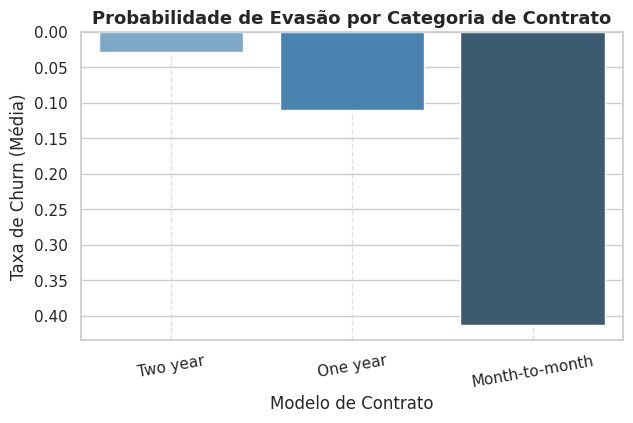

In [46]:
plt.figure(figsize=(7, 4))

# Cálculo da taxa média por contrato
taxa_contrato = df_plot.groupby('tipo_contrato')['evasao'].mean().sort_values()

# Plotagem com gradiente de azul (Azure/SteelBlue)
sns.barplot(x=taxa_contrato.index, y=taxa_contrato.values, hue=taxa_contrato.index,
            palette="Blues_d", legend=False)

plt.title('Probabilidade de Evasão por Categoria de Contrato', fontsize=13, fontweight='bold')
plt.ylabel('Taxa de Churn (Média)')
plt.xlabel('Modelo de Contrato')
plt.xticks(rotation=10)
plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

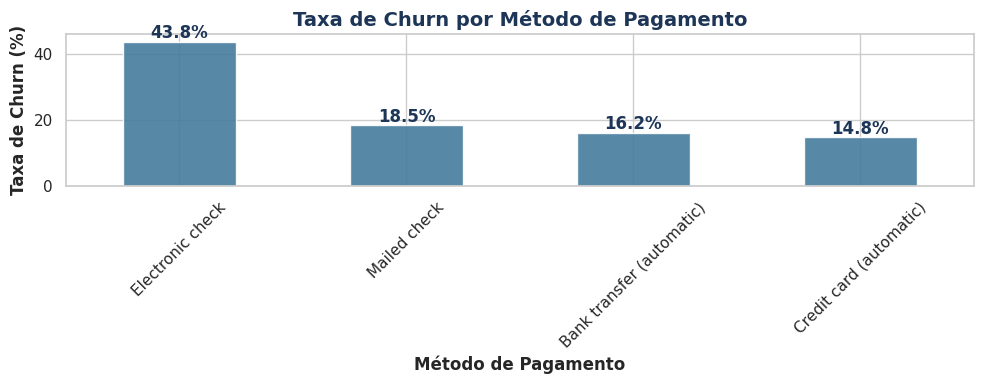

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# Definição da paleta para consistência visual
cor_principal = '#1d3557' # Azul Marinho (Títulos/Texto)
cor_barras = '#457b9d'    # Steel Blue (Dados)

plt.figure(figsize=(10, 4))

# Cálculo da taxa de evasão via crosstab para maior precisão estatística
churn_pagto = pd.crosstab(df_telecom['metodo_pagamento'], df_telecom['evasao'], normalize='index') * 100

# Plotagem da taxa de evasão (Status 1)
ax = churn_pagto[1].sort_values(ascending=False).plot(kind='bar', color=cor_barras, alpha=0.9)

plt.title('Taxa de Churn por Método de Pagamento', fontsize=14, fontweight='bold', color=cor_principal)
plt.ylabel('Taxa de Churn (%)', fontweight='bold')
plt.xlabel('Método de Pagamento', fontweight='bold')
plt.xticks(rotation=45)

# Inserção de rótulos de dados (Data Labels)
for j, v in enumerate(churn_pagto[1].sort_values(ascending=False).values):
    ax.text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', color=cor_principal)

plt.tight_layout()
plt.show()

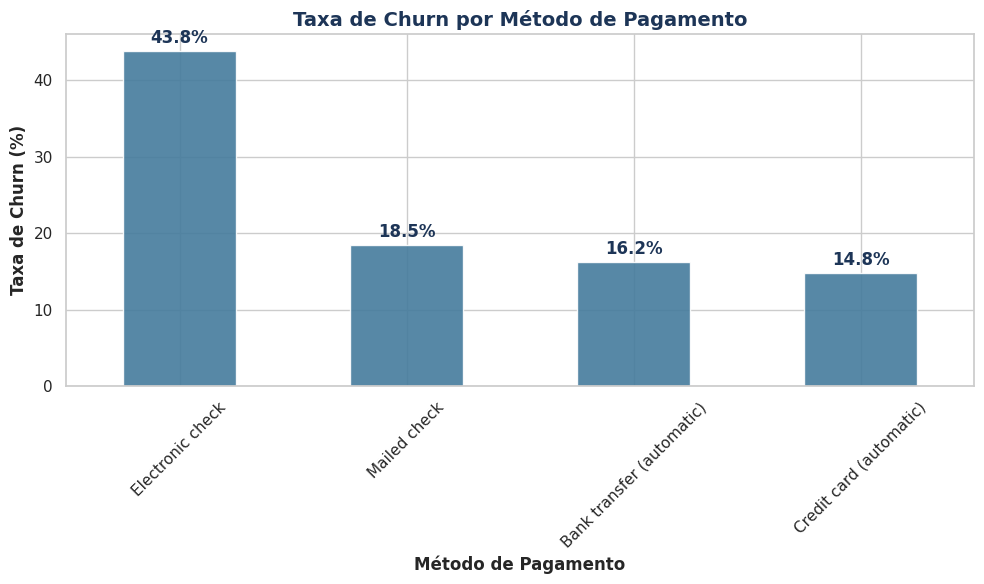

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Definição da paleta executiva
cor_principal = '#1d3557'
cor_barras = '#457b9d'

plt.figure(figsize=(10, 6))

# Cálculo da taxa de evasão por categoria
churn_pagto = pd.crosstab(df_telecom['metodo_pagamento'], df_telecom['evasao'], normalize='index') * 100

# Ordenação decrescente para destacar o maior risco
dados_plot_pagto = churn_pagto[1].sort_values(ascending=False)
ax = dados_plot_pagto.plot(kind='bar', color=cor_barras, alpha=0.9)

plt.title('Taxa de Churn por Método de Pagamento', fontsize=14, fontweight='bold', color=cor_principal)
plt.ylabel('Taxa de Churn (%)', fontweight='bold')
plt.xlabel('Método de Pagamento', fontweight='bold')
plt.xticks(rotation=45)

# Inserção de rótulos de dados
for j, v in enumerate(dados_plot_pagto.values):
    ax.text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', color=cor_principal)

plt.tight_layout()
plt.show()

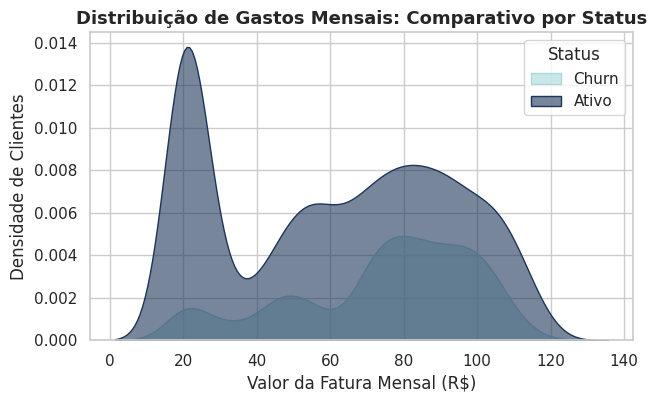

In [39]:
plt.figure(figsize=(7, 4))

# Comparativo de densidade com preenchimento suave
sns.kdeplot(data=df_plot, x='fatura_mensal', hue='evasao', fill=True,
            palette={0: '#1d3557', 1: '#a8dadc'}, alpha=0.6)

plt.title('Distribuição de Gastos Mensais: Comparativo por Status', fontsize=13, fontweight='bold')
plt.xlabel('Valor da Fatura Mensal (R$)')
plt.ylabel('Densidade de Clientes')

plt.legend(title='Status', labels=['Churn', 'Ativo'])
plt.show()

In [56]:
# 1. Preparação das métricas
insights = []

# Taxa geral de evasão
taxa_geral = df_telecom['evasao'].mean() * 100
insights.append(f"📊 Taxa Geral de Churn: {taxa_geral:.2f}%")

# Análise por Contrato (O maior ofensor)
churn_por_contrato = df_telecom.groupby('tipo_contrato')['evasao'].mean() * 100
pior_contrato = churn_por_contrato.idxmax()
insights.append(f"📄 Pior Modelo de Contrato: {pior_contrato} ({churn_por_contrato[pior_contrato]:.2f}% de evasão)")

# Análise por Método de Pagamento
churn_por_pagto = df_telecom.groupby('metodo_pagamento')['evasao'].mean() * 100
pior_pagto = churn_por_pagto.idxmax()
insights.append(f"💳 Canal Crítico de Pagamento: {pior_pagto} ({churn_por_pagto[pior_pagto]:.2f}% de evasão)")

# Análise por Tempo de Casa (Tenure)
churn_novos = df_telecom[df_telecom['meses_base'] <= 12]['evasao'].mean() * 100
churn_antigos = df_telecom[df_telecom['meses_base'] > 12]['evasao'].mean() * 100
insights.append(f"⏳ Churn em Clientes Novos (≤1 ano): {churn_novos:.2f}%")
insights.append(f"🏛️ Churn em Clientes Retidos (>1 ano): {churn_antigos:.2f}%")



# Ticket Médio de quem sai vs. quem fica
ticket_churn = df_telecom[df_telecom['evasao'] == 1]['fatura_mensal'].mean()
ticket_ativo = df_telecom[df_telecom['evasao'] == 0]['fatura_mensal'].mean()
insights.append(f"💰 Ticket Médio (Churn): R$ {ticket_churn:.2f} | (Ativos): R$ {ticket_ativo:.2f}")

# Perda Financeira Mensal Estimada (MRR Lost)
perda_mensal = df_telecom[df_telecom['evasao'] == 1]['fatura_mensal'].sum()
insights.append(f"📉 Impacto Financeiro (MRR Perdido): R$ {perda_mensal:,.2f} / mês")

# Risco por Tecnologia (Internet)
churn_fibra = df_telecom[df_telecom['servico_internet'] == 'Fiber optic']['evasao'].mean() * 100
insights.append(f"🌐 Risco Crítico em Fibra Óptica: {churn_fibra:.2f}%")

# Exibição Formatada
print("-" * 50)
print("📌 SUMÁRIO EXECUTIVO - TELECOM X")
print("-" * 50)
for insight in insights:
    print(insight)
print("-" * 50)

--------------------------------------------------
📌 SUMÁRIO EXECUTIVO - TELECOM X
--------------------------------------------------
📊 Taxa Geral de Churn: 25.72%
📄 Pior Modelo de Contrato: Month-to-month (41.32% de evasão)
💳 Canal Crítico de Pagamento: Electronic check (43.80% de evasão)
⏳ Churn em Clientes Novos (≤1 ano): 45.78%
🏛️ Churn em Clientes Retidos (>1 ano): 16.63%
💰 Ticket Médio (Churn): R$ 74.44 | (Ativos): R$ 61.35
📉 Impacto Financeiro (MRR Perdido): R$ 139,130.85 / mês
🌐 Risco Crítico em Fibra Óptica: 40.56%
--------------------------------------------------


####Análise de Diagnóstico: Telecom X

A análise dos dados da Telecom X revela que o churn não é distribuído de forma uniforme, concentrando-se em perfis específicos de consumo e métodos de faturamento. A taxa geral de evasão de 25,72% mascara pontos críticos de perda de receita qualificada.

1. Perfil do Cliente e Comportamento de Consumo
Os dados indicam que a empresa está perdendo seus clientes de maior valor. O ticket médio dos clientes que entraram em churn (R$ 74,44) é superior ao dos clientes ativos (R$ 61,35). Isso demonstra que a evasão impacta desproporcionalmente o faturamento bruto, gerando uma perda mensal recorrente (MRR) de aproximadamente R$ 139.130,85.

2. Gargalos Tecnológicos e Contratuais
O serviço de Fibra Óptica registra uma taxa de evasão de 40,56%, o que é atípico para uma tecnologia de alta performance. Somado a isso, o modelo de contrato mês a mês apresenta 41,32% de churn, confirmando que a facilidade de saída, combinada com possíveis instabilidades técnicas ou preços elevados na fibra, é o principal vetor de perda de base.

3. Impacto dos Processos Operacionais de Cobrança
Identificamos uma vulnerabilidade crítica no método de pagamento via Cheque Eletrônico, que atinge 43,80% de churn. Em contraste, clientes que utilizam métodos automáticos apresentam maior retenção. Isso sugere que processos de pagamento manuais aumentam o atrito e oferecem janelas mensais para a decisão de cancelamento.

4. Ciclo de Vida e Retenção Precoce
A maior pressão de evasão ocorre no primeiro ano de relacionamento. Clientes com até 12 meses de casa apresentam 45,78% de churn, enquanto aqueles que superam esse período inicial estabilizam a taxa em 16,63%. O foco da retenção deve ser, portanto, o suporte e a entrega de valor nos meses iniciais do contrato.

🚀 Recomendações de Negócio
Incentivo à Automação: Criar benefícios para a migração de clientes de métodos manuais para débito automático ou cartão de crédito.

Fidelização de Novos Entrantes: Implementar réguas de relacionamento e bônus progressivos focados especificamente no primeiro ano de permanência.

Revisão do Produto Fibra: Realizar uma auditoria técnica e de mercado sobre o serviço de fibra óptica para alinhar a estabilidade da entrega ao posicionamento de preço premium.